In [138]:
%loadlibs
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from scipy.integrate import solve_ivp
torch.set_default_device('mps')

Loaded libraries:
	- numpy (np)
	- matplotlib.pyplot (plt)
	- torch
	- torch.nn (nn)
	- torch.optim (optim)
	- tqdm


We play with the system

\begin{equation}
\begin{split}
    \dot{x}_1 &= x_1 + x_2\\
    \dot{x}_2 &= x_1 - 2 x_2
\end{split}
\end{equation}
where there is one fixed point $(0, 0)$, and two isoclines $x_1 = -x_2$ and $x_1 = 2 x_2$. We train a Neural Network taking $(x_1(0), x_2(0), t_0, t)$ as input.

In [115]:
class PINN(nn.Module):
    def __init__(self, layer_size=128):
        super().__init__()
        self.l1 = nn.Linear(4, layer_size)
        self.l2 = nn.Linear(layer_size, layer_size)
        self.l3 = nn.Linear(layer_size, layer_size)
        self.l4 = nn.Linear(layer_size, layer_size)
        self.l5 = nn.Linear(layer_size, layer_size)
        self.l6 = nn.Linear(layer_size, 2)
        self.activation = nn.Tanh()

    def forward(self, x1_0, x2_0, t0, t):
        x = torch.concatenate([x1_0, x2_0, t0, t], axis=-1)
        x = self.activation(self.l1(x))
        x = self.activation(self.l2(x))
        x = self.activation(self.l3(x))
        x = self.activation(self.l4(x))
        x = self.activation(self.l5(x))
        return t0**2 * self.l6(x) + torch.concatenate([x1_0, x2_0], axis=-1)

In [116]:
def loss_physics(model, x1_0, x2_0, t0, t):
    outputs = model(x1_0, x2_0, t0, t)
    x1, x2 = outputs[:, 0], outputs[:, 1]
    loss_x1 = ((x1+x2 - torch.autograd.grad(x1, t, grad_outputs=torch.ones_like(x1), create_graph=True)[0])**2).mean()
    loss_x2 = ((x1 - 2*x2 - torch.autograd.grad(x1, t, grad_outputs=torch.ones_like(x1), create_graph=True)[0])**2).mean()
    return loss_x1 + loss_x2

We know that if $f^{\text{NN}}$ is a correct solution operator that gives
$$f^{\text{NN}}(x_1(t_0), x_2(t_0), t)) = (x_1(t), x_2(t)),$$
then
$$f^{\text{NN}}(x_1(t_0), x_2(t_0), t+1) = f^{\text{NN}}(x_1(t), x_2(t), 1),$$
and this could enforce coherence of the trajectories and the phase portrait along time.

In [117]:
def loss_phase_portrait(model, x1_0, x2_0, t0, t):
    x1x2 = model(x1_0, x2_0, t0, t)
    x1, x2 = x1x2[:, 0:1], x1x2[:, 1:2]
    dt = torch.rand(t.shape)*5.
    x1x2_1 = model(x1_0, x2_0, t0+dt, t+dt)
    x1x2_2 = model(x1, x2, t, dt)
    loss_trajectories = ((x1x2_1 - x1x2_2)**2).mean()
    loss_phase_portrait = ((torch.autograd.grad(x1x2_1, t, grad_outputs=torch.ones_like(x1x2_1), create_graph=True)[0]-torch.autograd.grad(x1x2_2, t, grad_outputs=torch.ones_like(x1x2_2), create_graph=True)[0])**2).mean()
    return loss_trajectories, loss_phase_portrait

In [135]:
n_points = 5000
n_epochs = 5000
T_MAX = 5.
model = PINN()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

for _ in (pbar:=tqdm(range(n_epochs))):
    optimizer.zero_grad()
    x1_0 = torch.rand((n_points, 1), requires_grad=True)
    x2_0 = torch.rand((n_points, 1), requires_grad=True)
    t0 = torch.rand((n_points, 1), requires_grad=True)
    t = t0 + torch.rand((n_points, 1), requires_grad=True) * (T_MAX-t0)
    loss1 = loss_physics(model, x1_0, x2_0, t0, t)
    loss2, loss3 = loss_phase_portrait(model, x1_0, x2_0, t0, t)
    loss = loss1# + loss2 + loss3
    loss.backward()
    optimizer.step()
    pbar.set_description(f"Loss: {loss.item():.4e}")

  0%|          | 0/5000 [00:00<?, ?it/s]

We plot some trajectories.

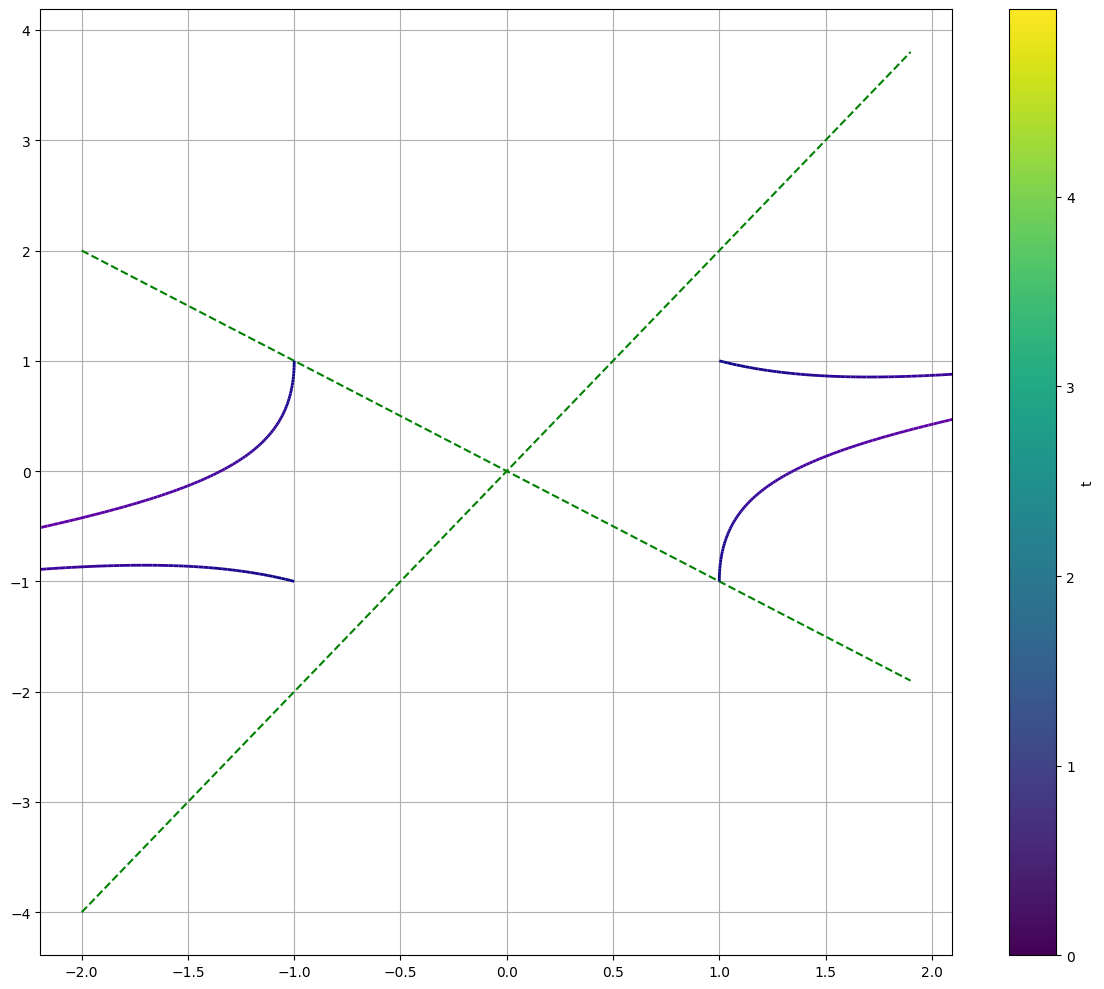

In [136]:
t = torch.arange(0, T_MAX, 0.01).unsqueeze(-1)
x1_0 = [-1, -1, 1, 1]
x2_0 = [-1, 1, -1, 1]

def f(t, x):
    return [x[0] + x[1], x[0] - 2*x[1]]

t_eval = t.cpu().squeeze().numpy()
sols = {}
for i in range(len(x1_0)):
    sols[(x1_0[i], x2_0[i])] = solve_ivp(f, [0, T_MAX], [x1_0[i], x2_0[i]], t_eval=t_eval).y.T

x1 = torch.arange(-2, 2, 0.1).cpu()

fig, ax = plt.subplots(figsize=(12, 10))
ax.plot(x1, -x1, linestyle='dashed', color='green')
ax.plot(x1, 2*x1, linestyle='dashed', color='green')

t_np = t.squeeze(-1).cpu().numpy()
norm = Normalize(vmin=t_np.min(), vmax=t_np.max())
cmap = plt.get_cmap('viridis')
cmap_num = plt.get_cmap('plasma')

for i in range(len(x1_0)):
    x1_val, x2_val = x1_0[i], x2_0[i]
    trajectory = model(torch.ones_like(t)*x1_val, torch.ones_like(t)*x2_val, torch.zeros_like(t), t).detach().cpu().numpy()
    points = trajectory[:, :2].reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    lc = LineCollection(segments, cmap=cmap, norm=norm)
    lc.set_array(t_eval[:-1])
    lc.set_linewidth(2)
    ax.add_collection(lc)

    points = sols[(x1_val, x2_val)].reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    lc = LineCollection(segments, cmap=cmap_num, norm=norm)
    lc.set_array(t_eval[:-1])
    lc.set_linewidth(2)
    ax.add_collection(lc)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label='t')
#ax.set_xlim([-1, 1])
#ax.set_ylim([-1, 1])
ax.grid()
plt.tight_layout()
plt.show()

In [137]:
n_grid = 20
gx1, gx2 = torch.meshgrid(
    torch.linspace(-1, 1, n_grid),
    torch.linspace(-1, 1, n_grid),
    indexing='xy'
)
gx1 = gx1.reshape(-1, 1)
gx2 = gx2.reshape(-1, 1)


t_eval = torch.ones_like(gx1, requires_grad=True) * 1

out = model(gx1, gx2, t_eval)
x1_out = out[:, 0:1]
x2_out = out[:, 1:2]

dx1_dt = torch.autograd.grad(
    outputs=x1_out, inputs=t_eval,
    grad_outputs=torch.ones_like(x1_out),
    retain_graph=True, create_graph=False
)[0]

dx2_dt = torch.autograd.grad(
    outputs=x2_out, inputs=t_eval,
    grad_outputs=torch.ones_like(x2_out),
    retain_graph=False, create_graph=False
)[0]

gx1_np = gx1.detach().cpu().numpy().flatten()
gx2_np = gx2.detach().cpu().numpy().flatten()
dx1_np = dx1_dt.detach().cpu().numpy().flatten()
dx2_np = dx2_dt.detach().cpu().numpy().flatten()

ax.quiver(
    gx1_np, gx2_np, dx1_np, dx2_np,
    angles='xy', scale_units='xy', scale=None,
    color='black', alpha=0.6, width=0.003
)

ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.grid()
plt.tight_layout()
plt.show()

TypeError: PINN.forward() missing 1 required positional argument: 't'